In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("spam_detection_dataset.csv")
df.head()

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
0,3,98,1,0.718607,0,0
1,0,170,0,0.698901,1,0
2,0,38,0,0.620466,0,0
3,0,116,0,0.701755,0,0
4,3,89,1,0.583621,1,1


In [3]:
df.shape

(20000, 6)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_links     20000 non-null  int64  
 1   num_words     20000 non-null  int64  
 2   has_offer     20000 non-null  int64  
 3   sender_score  20000 non-null  float64
 4   all_caps      20000 non-null  int64  
 5   is_spam       20000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 937.6 KB


In [5]:
df.isnull().sum()

num_links       0
num_words       0
has_offer       0
sender_score    0
all_caps        0
is_spam         0
dtype: int64

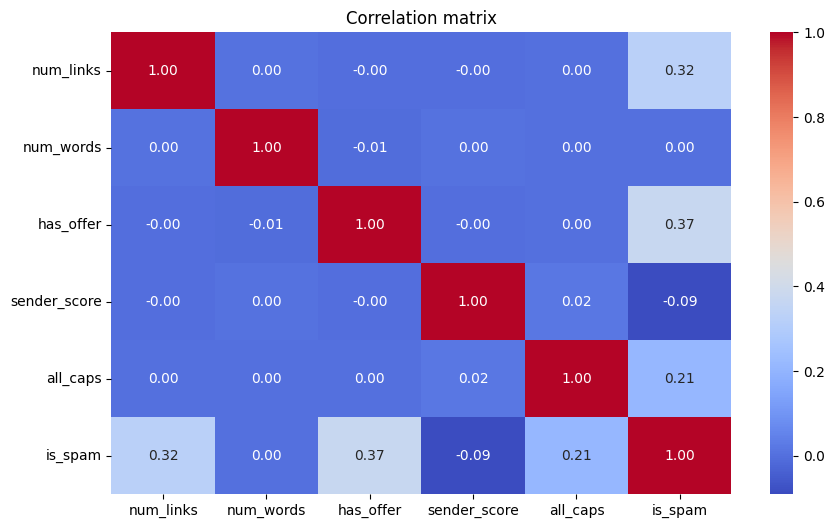

In [6]:
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation matrix")
plt.show()

The relationship of `is_spam` is little to non-existent with variables like `num_words` and `sender_score`, so removing them for simplicity and better model prediction ability of linear model.

In [7]:
df = df.drop(columns=['sender_score', 'num_words'])
df.head()

,num_links,has_offer,all_caps,is_spam
0,3,1,0,0
1,0,0,1,0
2,0,0,0,0
3,0,0,0,0
4,3,1,1,1


### Working on splitting the dataset

In [8]:
X = df.drop("is_spam", axis=1)
y = df["is_spam"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

### Implementing Logistic Regression from Scratch

In [ ]:
class LogisticRegression:
    def __init__(self, learning_rate: float = 0.01, n_iters: float = 500):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.losses = []
    
    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def compute_loss(self, y_true, y_pred):
        epsilon = 1e-9
        y1 = y_true * np.log(y_pred + epsilon)
        y2 = (1-y_true) * np.log(1-y_pred + epsilon)
        return -np.mean(y1+y2)
    
    def feed_forward(self, X):
        z = np.dot(X, self.weights) + self.bias
        A = self._sigmoid(z)
        return A
    
    def fit(self, X, y):
        n_samples, n_features = X.shape

        X = np.array(X)
        y = np.array(y)

        # init parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # gradient descent
        for _ in range(self.n_iters):
            A = self.feed_forward(X)
            self.losses.append(self.compute_loss(y,A))
            dz = A - y # derivative of sigmoid and bce X.T*(A-y)
            # compute gradients
            dw = (1 / n_samples) * np.dot(X.T, dz)
            db = (1 / n_samples) * np.sum(dz)
            # update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        threshold = .3
        y_hat = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(y_hat)
        y_predicted_cls = [1 if i > threshold else 0 for i in y_predicted]
        return np.array(y_predicted_cls)

### Scaling the values

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [12]:
regressor = LogisticRegression(learning_rate=0.001, n_iters=1000)
regressor.fit(X_train_scaled, y_train)
predictions = regressor.predict(X_test_scaled)

### Compute the evaluation metrics

In [13]:
tp, tn, fp, fn = 0, 0, 0, 0

y_test_arr = np.array(y_test)

tp = np.sum((predictions == 1) & (y_test_arr == 1))
tn = np.sum((predictions == 0) & (y_test_arr == 0))
fp = np.sum((predictions == 1) & (y_test_arr == 0))
fn = np.sum((predictions == 0) & (y_test_arr == 1))

print("True positive: ", tp)
print("False positive: ", fp)
print("True negative: ", tn)
print("False negative: ", fn)

True positive:  49
False positive:  4
True negative:  3630
False negative:  317


In [14]:
print("The evaluation metrics scores are: ")
try:
    precision = tp / (tp+fp)
    print("Precision: ", precision)
except Exception as e:
    print("Couldn't calculate precision")

try:
    recall = tp / (tp+fn)
    print("Recall: ", recall)
except Exception as e:
    print("Couldn't calculate recall")

try:
    f1 = (2 * precision * recall)/(precision + recall)
    print("F1-score: ", f1)
except Exception as e:
    print("Couldn't calculate f1-score")


The evaluation metrics scores are: 
Precision:  0.9245283018867925
Recall:  0.13387978142076504
F1-score:  0.23389021479713606


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      3634
           1       0.92      0.13      0.23       366

    accuracy                           0.92      4000
   macro avg       0.92      0.57      0.60      4000
weighted avg       0.92      0.92      0.89      4000



### Handling the imbalanced data by applying SMOTE(Synthetic Minority Over-sampling Technique)

In [20]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Split FIRST (keep the test set pure)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Apply SMOTE ONLY to the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 3. Fit the model on balanced training data
regressor = LogisticRegression(learning_rate=0.001, n_iters=1000)
regressor.fit(X_train_balanced, y_train_balanced)

# 4. Predict on the original, imbalanced test data
predictions = regressor.predict(X_test)

# 5. Check results
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.17      0.29      3631
           1       0.11      1.00      0.20       369

    accuracy                           0.24      4000
   macro avg       0.55      0.58      0.24      4000
weighted avg       0.92      0.24      0.28      4000



In [19]:
from sklearn.ensemble import RandomForestClassifier

regressor = RandomForestClassifier(class_weight='balanced', random_state=42)
regressor.fit(X_train, y_train) # Use the original imbalanced training data

predictions = regressor.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3631
           1       0.78      0.78      0.78       369

    accuracy                           0.96      4000
   macro avg       0.88      0.88      0.88      4000
weighted avg       0.96      0.96      0.96      4000

